# 01 · Data Understanding
Exploration of the CDC Nutrition, Physical Activity, and Obesity (BRFSS) dataset.
This first step is **crucial** beacuse one is able to understand the variables, make cleaning processes when need it and have a broad perspective of the problem to solve ☝️  

# Data Validation   
At this first step, I'm trying to really understand how is shaped my dataset. This step is really important because I know what I'm working with.

In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("../data/raw/Data_BRFSS.csv")
print(df.shape)
print(df.columns)

(110880, 33)
Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
       'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ',
       'Sample_Size', 'Total', 'Age(years)', 'Education', 'Sex', 'Income',
       'Race/Ethnicity', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'LocationID', 'StratificationCategory1',
       'Stratification1', 'StratificationCategoryId1', 'StratificationID1'],
      dtype='str')


C:\Users\Juan David Castillo\AppData\Local\Temp\ipykernel_23816\3244810769.py:5: DtypeWarning: Columns (8: Data_Value_Unit) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/Data_BRFSS.csv")


In [2]:
space=75

df.columns=(
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

duplicates=df.duplicated().sum()

space=75
print("="*space)
print("Columns fixed".center(75))
print("="*space)
print("\n")
print(df.columns)

print("\n")
print("="*space)
print("Duplicates in the DataSet--->",duplicates)
print("="*space)
print("\n")

nulls=df.isnull().sum()
nulls=nulls[nulls>0].sort_values(ascending=False)
print("="*space)
msg = f"From the {df.shape[1]} columns in the dataset {len(nulls)} have nulls"
print(msg.center(75))
print("="*space)
print(nulls)




                               Columns fixed                               


Index(['yearstart', 'yearend', 'locationabbr', 'locationdesc', 'datasource',
       'class', 'topic', 'question', 'data_value_unit', 'data_value_type',
       'data_value', 'data_value_alt', 'data_value_footnote_symbol',
       'data_value_footnote', 'low_confidence_limit', 'high_confidence_limit',
       'sample_size', 'total', 'age_years', 'education', 'sex', 'income',
       'race_ethnicity', 'geolocation', 'classid', 'topicid', 'questionid',
       'datavaluetypeid', 'locationid', 'stratificationcategory1',
       'stratification1', 'stratificationcategoryid1', 'stratificationid1'],
      dtype='str')


Duplicates in the DataSet---> 0


              From the 33 columns in the dataset 15 have nulls             
total                         106920
data_value_unit               106260
sex                           102960
data_value_footnote            97666
data_value_footnote_symbol     97666
education   

# Outliers
It's important to work only with valuable data. In this way, we are going to avoid bias in the results and the conclusions are going to be more accurate.

It worth it to see what's the most accurate method to discover outliers in this dataset. Generally, one can do it by groups or detect them by groups. In this analysis, I'm going to do by both generally and by groups, and see what insights brings each.


## The entire dataset


In [4]:
def outliers_detection(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    mask = (data[col] > upper_limit) | (data[col] < lower_limit)
    return mask, lower_limit, upper_limit


numeric_cols = ["data_value"]
outlier_mask = pd.Series([False] * len(df), index=df.index)

for col in numeric_cols:
    mask, lower, upper = outliers_detection(df, col)
    outlier_mask = outlier_mask | mask

df_outlier=df[outlier_mask]
df_clean=df[~outlier_mask]

outliers_count=df_outlier.shape[0]
print(f"Outliers detected by this method--->{outliers_count}")
print("\n")
count_answer=df_outlier['question'].value_counts().sort_values(ascending=False)

print("Outliers detected by question".center(80))
print("\n")
print(count_answer)





Outliers detected by this method--->2496


                         Outliers detected by question                          


question
Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)                                                                                    2236
Percent of adults aged 18 years and older who have obesity                                                                                                                                                                                                                                73
Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week      40
Percent of

# Red flag 🚩
Detecting the outliers taking into account all the data set ( with out a group division) it's bringing **2496** outliers. However, as is evident below, almost 90% of those outliers come from the question *Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)*. Thus, is evident that this method does not really work. We have to divided into groups for really see what is an atipical value, and the most accurate method is grouping by **question**.

# Outliers detection by question ❓❔

In [41]:
# 1. remove the suppressed rows (no value to analyse)
df_valid = df.dropna(subset=["data_value"])
print("rows with a value:", len(df_valid), "| dropped:", len(df) - len(df_valid))

# 2. detect outliers on that subset
col = "data_value"
outlier_mask = pd.Series([False] * len(df_valid), index=df_valid.index)
bounds = {}

for question, group in df_valid.groupby("questionid"):
    mask, lower, upper = outliers_detection(group, col)
    outlier_mask.loc[group.index] = mask
    bounds[question] = (lower, upper)
    print(f"{question}: [{lower:6.2f}, {upper:6.2f}]  ->  {mask.sum():4d} outliers")

# 3. split
df_outlier = df_valid[outlier_mask]
df_clean   = df_valid[~outlier_mask]

print("\nstart:", len(df), "| no nulls:", len(df_valid),
      "| outliers:", outlier_mask.sum(), "| clean:", len(df_clean))


df_clean.to_csv(r"C:\Users\Juan David Castillo\OneDrive\Python\prove14.csv")
df_valid.to_csv(r"C:\Users\Juan David Castillo\OneDrive\Python\prove15.csv")

rows with a value: 97666 | dropped: 13214
Q018: [ 23.25,  56.45]  ->    52 outliers
Q019: [  4.45,  36.85]  ->   148 outliers
Q036: [ 14.00,  49.20]  ->   634 outliers
Q037: [ 23.30,  45.70]  ->   527 outliers
Q043: [ 28.65,  73.85]  ->    66 outliers
Q044: [  4.25,  39.05]  ->    85 outliers
Q045: [ 13.50,  51.10]  ->   118 outliers
Q046: [  9.65,  54.85]  ->    67 outliers
Q047: [  3.40,  47.40]  ->   247 outliers

start: 110880 | no nulls: 97666 | outliers: 1944 | clean: 95722


This a pretty much more precise calculation for outliers! We have detected what really is an atipical point into every single question: a value of 50 is not the same in Q046 than Q047. Now, we are completelly sure that we have clean and reliable data for work on this project! 

## General information

First, let's find out some interesting information of the data. For example, let´s plot what's the state with more information.

<function matplotlib.pyplot.show(close=None, block=None)>

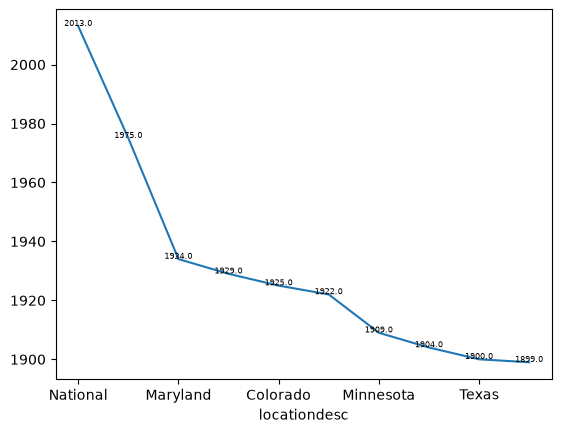

In [ ]:
import matplotlib.pyplot as plt
count_per_state=df.groupby('locationdesc')['data_value'].count().sort_values(ascending=False).nlargest(10)
count_per_state.plot(kind='bar')
for i, valor in enumerate(count_per_state):
    plt.text(i, valor + 0.1, f'{valor:.1f}', ha='center', fontsize=6, color='black')

plt.show